In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import datasets
import unet
import unetFixed
from SplitNet import SplitNet


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Model loading
# -----------------------------

def infer_model_type(path):
    p = path.lower()

    if "splitnet_attn" in p:
        return "splitnet_attn"
    if "splitnet" in p:
        return "splitnet"
    if "attn_unet" in p:
        return "attn_unet"
    if "unetfixed" in p or "prof_unet" in p:
        return "unetfixed"
    if "unet" in p:
        return "unet"

    raise ValueError(f"Could not infer model type from path: {path}")


def infer_dataset_mode(path):
    p = path.lower()

    if "border" in p:
        return "border"
    if "fixed" in p:
        return "fixed"

    raise ValueError(f"Could not infer fixed/border from path: {path}")


def infer_training_mode(path):
    p = path.lower()

    if "physics_limited" in p:
        return "physics_limited"
    if "baseline_full" in p:
        return "baseline_full"

    # default guess
    return "physics_limited"


def make_model(model_type, channels="KP"):
    if channels == "KP":
        num_channels = 2
    elif channels == "all":
        num_channels = 3
    else:
        num_channels = 1

    if model_type == "splitnet_attn":
        return SplitNet(attn=True).to(DEVICE)
    if model_type == "splitnet":
        return SplitNet(attn=False).to(DEVICE)
    if model_type == "unet":
        return unet.SmallUnet(channels=num_channels).to(DEVICE)
    if model_type == "attn_unet":
        return unet.AttnUnet(channels=num_channels).to(DEVICE)
    if model_type == "unetfixed":
        return unetFixed.UNet(
            in_channels=num_channels,
            num_classes=num_channels,
        ).to(DEVICE)

    raise ValueError(f"Unknown model type: {model_type}")


def load_model_from_path(path, channels="KP"):
    model_type = infer_model_type(path)
    model = make_model(model_type, channels=channels)

    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    return model


# -----------------------------
# Channel handling
# -----------------------------

def channel_indices(channels):
    if channels == "all":
        return [0, 1, 2]
    if channels == "KP":
        return [0, 1]
    if channels == "K":
        return [0]
    if channels == "P":
        return [1]
    if channels == "phi":
        return [2]
    raise ValueError("Bad channels")


# -----------------------------
# Rebuild visual item
# -----------------------------

def build_visual_item(
    model_path,
    idx,
    val_sims_path="../val_sims.npy",
    sim_max_exclusive=500,
    channels="KP",
    points_per_side=3,
    radius=5,
    steps=(0, 200),
    seed=123,
):
    """
    Returns:
        feat  = model input
        target = full actual image

    This avoids the Limited dataset problem where label is only hidden dots.
    """

    dataset_mode = infer_dataset_mode(model_path)
    training_mode = infer_training_mode(model_path)

    sims = np.load(val_sims_path)

    if sim_max_exclusive is not None:
        sims = sims[sims < sim_max_exclusive]

    num_steps = steps[1] - steps[0]
    sim_idx = (idx // num_steps) % len(sims)
    sim_step = (idx % num_steps) + steps[0]

    # Full actual target at next step
    target = torch.tensor(
        datasets.get_all(sims[sim_idx], sim_step + 1, datasets.BINARY_FOLDER)
    )

    feat = torch.zeros_like(target)

    H, W = target.shape[-2], target.shape[-1]
    mask_input = torch.zeros((H, W), dtype=torch.bool)

    if dataset_mode == "fixed":
        div = points_per_side + 1
        point_x = np.arange(W // div, W, W // div)
        point_y = np.arange(H // div, H, H // div)

        yy, xx = torch.meshgrid(
            torch.arange(H),
            torch.arange(W),
            indexing="ij",
        )

        if training_mode == "physics_limited":
            # Match FixedDenseDatasetLimited input behavior:
            # sample gets random subset of points.
            rng = np.random.default_rng(seed + idx)
            show = rng.choice(
                points_per_side ** 2,
                size=(points_per_side - 1) ** 2,
                replace=False,
            )

            p = 0
            for y0 in point_y:
                for x0 in point_x:
                    disk = (yy - int(y0)) ** 2 + (xx - int(x0)) ** 2 <= radius ** 2
                    if p in show:
                        mask_input |= disk
                    p += 1

        else:
            # Match FixedDenseDatasetFull input behavior:
            # input gets all fixed sensor points.
            for y0 in point_y:
                for x0 in point_x:
                    disk = (yy - int(y0)) ** 2 + (xx - int(x0)) ** 2 <= radius ** 2
                    mask_input |= disk

    elif dataset_mode == "border":
        if training_mode == "physics_limited":
            # Match BorderDenseDatasetLimited sample input:
            # only top and bottom boundary strips.
            mask_input[0:5, :] = True
            mask_input[-5:, :] = True
        else:
            # Match BorderDenseDatasetFull input:
            mask_input[0:5, :] = True
            mask_input[-5:, :] = True

    else:
        raise ValueError(f"Unknown dataset_mode: {dataset_mode}")

    chans = channel_indices(channels)
    feat[chans, :, :] = torch.where(
        mask_input.unsqueeze(0),
        target[chans, :, :],
        torch.zeros_like(target[chans, :, :]),
    )

    return feat[chans], target[chans]


# -----------------------------
# Visualization
# -----------------------------

def vis(x):
    return x.detach().cpu().numpy()


def show_model_evaluation(
    model_path,
    indices,
    channels="KP",
    val_sims_path="../val_sims.npy",
    sim_max_exclusive=500,
    save_path=None,
    vmin=-1,
    vmax=1,
):
    model = load_model_from_path(model_path, channels=channels)

    fig, axs = plt.subplots(
        len(indices),
        6,
        figsize=(12, 2.4 * len(indices)),
        dpi=200,
        squeeze=False,
    )

    titles = [
        "Given K",
        "Predicted K",
        "Actual K",
        "Given Pres",
        "Predicted Pres",
        "Actual Pres",
    ]

    for j, title in enumerate(titles):
        axs[0, j].set_title(title, fontsize=10)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            feat, target = build_visual_item(
                model_path=model_path,
                idx=idx,
                val_sims_path=val_sims_path,
                sim_max_exclusive=sim_max_exclusive,
                channels=channels,
            )

            pred = model(feat.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

            axs[row, 0].imshow(vis(feat[0]), cmap="gray", vmin=vmin, vmax=vmax)
            axs[row, 1].imshow(vis(pred[0]), cmap="gray", vmin=vmin, vmax=vmax)
            axs[row, 2].imshow(vis(target[0]), cmap="gray", vmin=vmin, vmax=vmax)

            axs[row, 3].imshow(vis(feat[1]), cmap="gray", vmin=vmin, vmax=vmax)
            axs[row, 4].imshow(vis(pred[1]), cmap="gray", vmin=vmin, vmax=vmax)
            axs[row, 5].imshow(vis(target[1]), cmap="gray", vmin=vmin, vmax=vmax)

    for ax in fig.get_axes():
        ax.axis("off")

    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=200)

    plt.show()

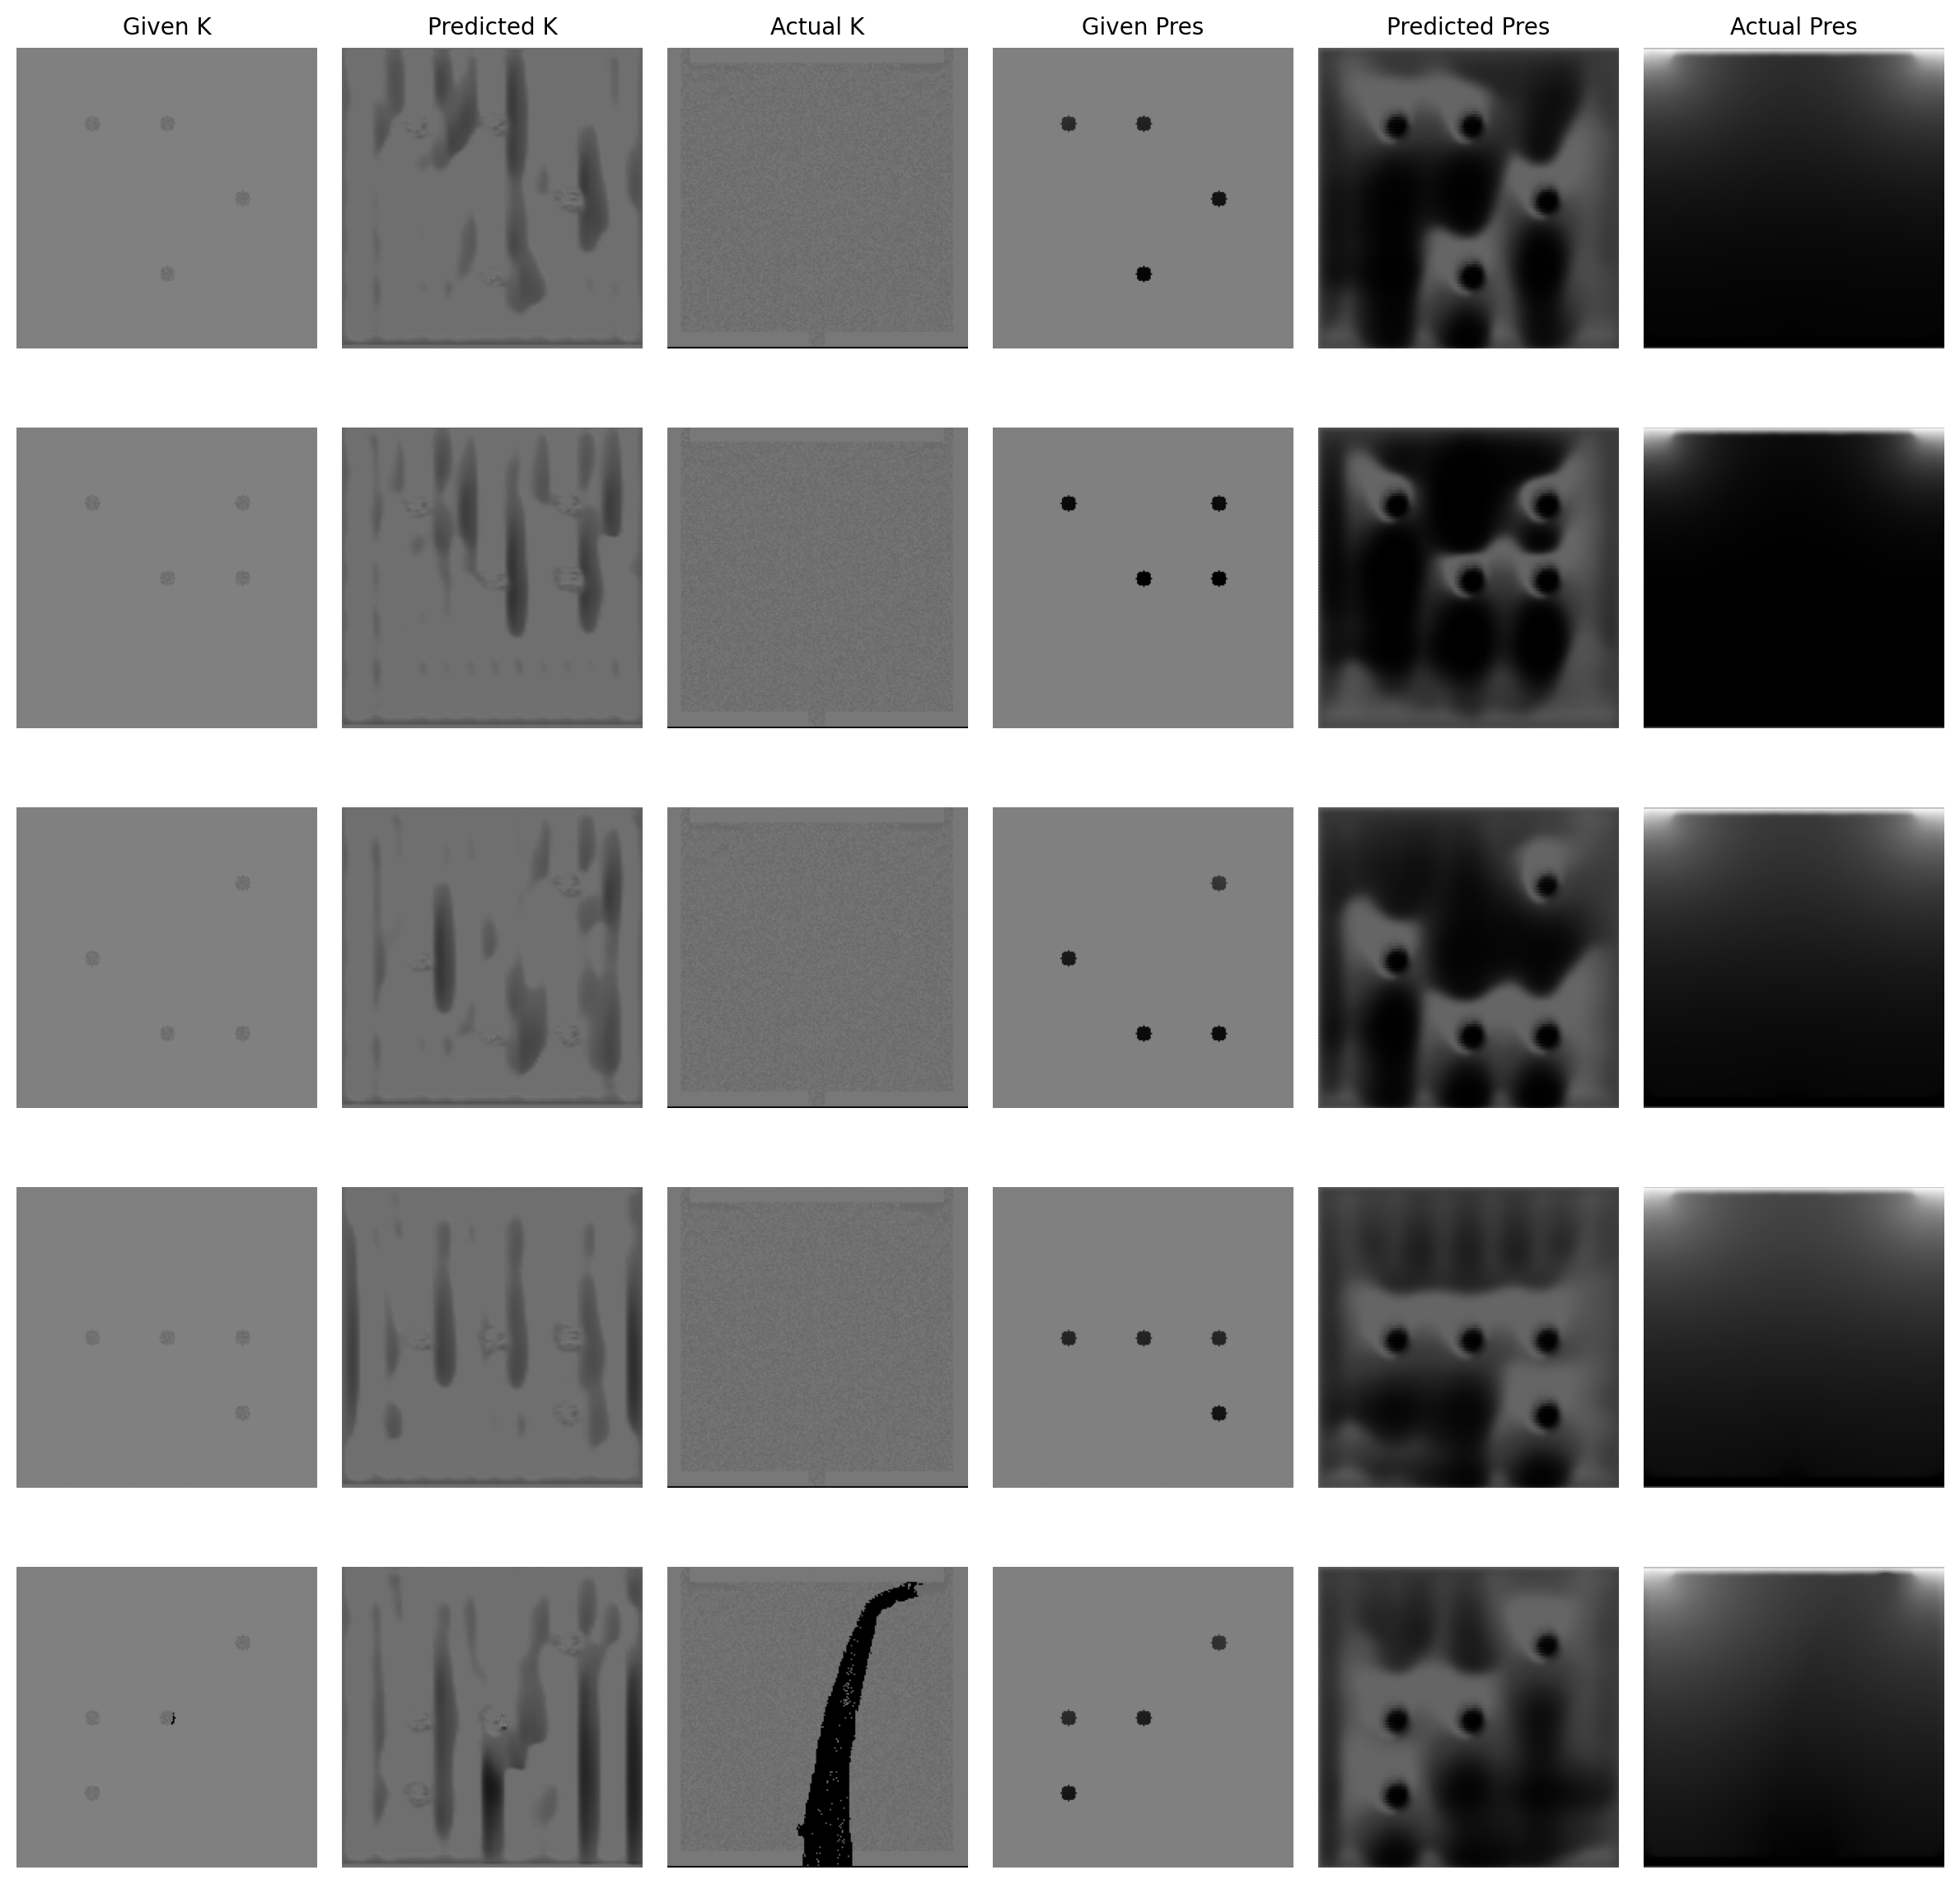

In [14]:
show_model_evaluation(
    model_path="calibration_loss_tests/fixed_splitnet_physics_limited_old_darcy_1_final_state.pt",
    indices=[9, 2, 12, 17, 100],
    channels="KP",
    sim_max_exclusive=500,
    save_path="eval_fixed_splitnet.png",
)

In [1]:
import torch
import matplotlib.pyplot as plt

from model_loader import make_model
import datasets

In [2]:
import torch
import datasets
import matplotlib.pyplot as plt

from model_loader import make_model, DEVICE

model = make_model(
    model_type="attn_unet",
    channels="KP"
)
model.load_state_dict(torch.load(
    "official_darcy/final/fixed_physics_limited_attn_unet_darcy_0p1_best_state.pt",
    map_location=DEVICE
))

model.eval()

C:\Users\jaden\AppData\Local\Temp\ipykernel_64448\3399619182.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


AttnUnet(
  (c1): TwoConv(
    (seq): Sequential(
      (0): Conv2d(2, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (d1): Downsample(
    (conv): TwoConv(
      (seq): Sequential(
        (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (d2): Downsample(


In [3]:
val_sims = [450]

dataset = datasets.FixedDenseDatasetLimited(
    sims=val_sims,
    channels="KP"
)

feat, label, mask = dataset[0]

with torch.no_grad():
    pred = model(feat.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(label[1].cpu())
plt.title("True Pressure")

plt.subplot(1, 2, 2)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()